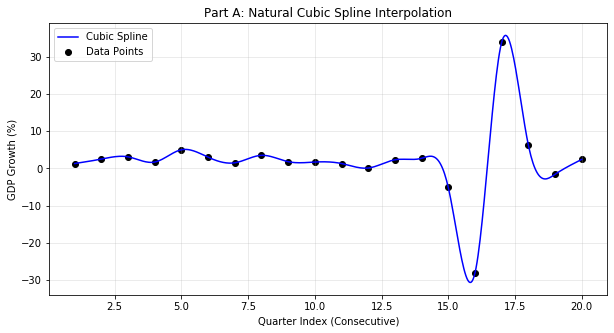

<ipython-input-17-fae5b74b11d8>:87: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.
  ax2.stem(x_data, y_data - poly_y)


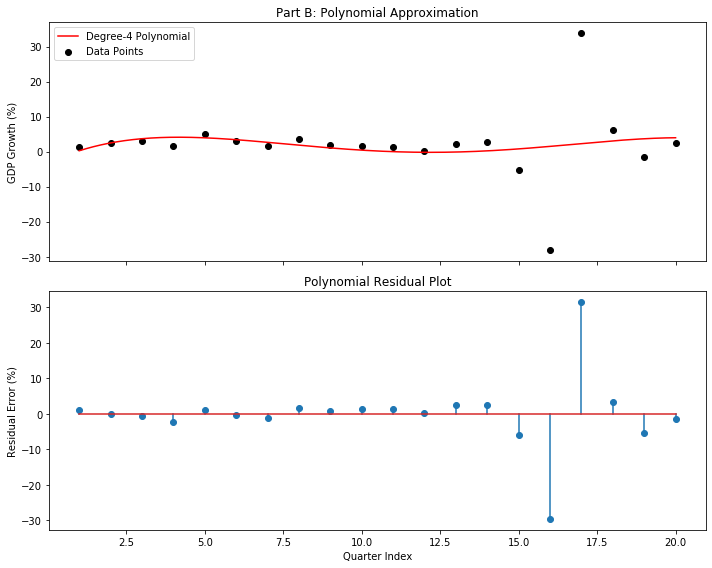

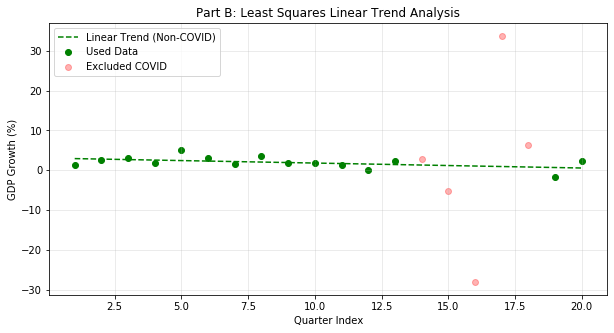

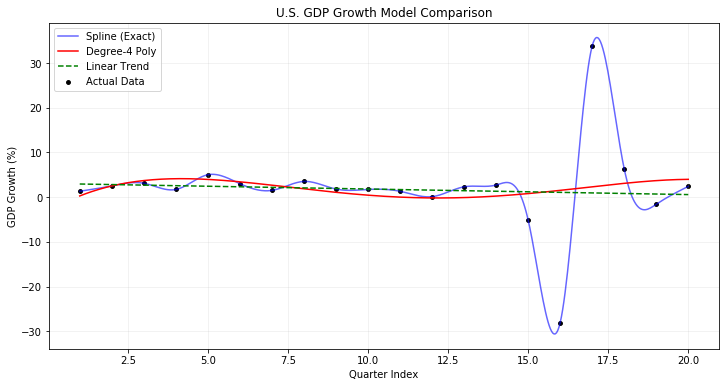

In [17]:
import numpy as np
import matplotlib.pyplot as plt


x_data = np.arange(1, 21) 
y_data = np.array([
    1.3, 2.5, 3.1, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.7,  
    1.3, 0.1, 2.3, 2.7, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4 
])#Setting up all data from the GDP report


def setup_tridiagonal_matrix(x, y):#Sets up our full matrix allowing us to create all of our custom models
    n = len(x)
    h = np.diff(x)
    A, B, C, D = np.zeros(n-2), np.zeros(n-2), np.zeros(n-2), np.zeros(n-2)
    for i in range(1, n-1):
        idx = i - 1
        if i > 1: A[idx] = h[i-1]
        B[idx] = 2 * (h[i-1] + h[i])
        if i < n-2: C[idx] = h[i]
        term1 = (y[i+1] - y[i]) / h[i]
        term2 = (y[i] - y[i-1]) / h[i-1]
        D[idx] = 6 * (term1 - term2)
    return A, B, C, D

def thomas_algorithm(a, b, c, d):#Solves the second derivatives for the spline 
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_data, y_data, M, x_eval):# Spline algorithm to create the exact fit based on our data
    n = len(x_data)
    h = np.diff(x_data)
    idx = np.searchsorted(x_data, x_eval) - 1
    idx = max(0, min(idx, n-2))
    hi, dx = h[idx], x_eval - x_data[idx]
    ai, ci = y_data[idx], M[idx] / 2.0
    di = (M[idx+1] - M[idx]) / (6.0 * hi)
    bi = (y_data[idx+1] - y_data[idx])/hi - (hi * (2.0*M[idx] + M[idx+1]))/6.0
    return ai + bi*dx + ci*(dx**2) + di*(dx**3)

def custom_poly_fit(x, y, degree):#polynomial fit for the data based on the vandermode matrix
    V = np.vander(x, degree + 1, increasing=True)
    coeffs = np.linalg.solve(V.T @ V, V.T @ y)
    y_fit = V @ coeffs
    return coeffs, y_fit


#sets the spline algorithm
A_t, B_t, C_t, D_t = setup_tridiagonal_matrix(x_data, y_data)
M_vals = np.zeros(len(x_data))
M_vals[1:-1] = thomas_algorithm(A_t, B_t, C_t, D_t)
x_smooth = np.linspace(x_data.min(), x_data.max(), 500)
y_spline = [evaluate_spline(x_data, y_data, M_vals, val) for val in x_smooth]
#sets the polynomial for our data 
poly_coeffs, poly_y = custom_poly_fit(x_data, y_data, 4)
y_poly_smooth = [np.polyval(poly_coeffs[::-1], val) for val in x_smooth]
#least squares model for our data
mask = (x_data < 14) | (x_data > 18)
lin_coeffs, _ = custom_poly_fit(x_data[mask], y_data[mask], 1)
y_linear = lin_coeffs[0] + lin_coeffs[1] * x_data

#Plot for the spline algorithm
plt.figure(figsize=(10, 5))
plt.scatter(x_data, y_data, color='black', label='Data Points')
plt.plot(x_smooth, y_spline, 'b-', label='Cubic Spline')
plt.title('Part A: Natural Cubic Spline Interpolation')
plt.xlabel('Quarter Index (Consecutive)')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#Plot for the 4th degree polynomial fit and residual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.scatter(x_data, y_data, color='black', label='Data Points')
ax1.plot(x_smooth, y_poly_smooth, 'r-', label='Degree-4 Polynomial')
ax1.set_title('Part B: Polynomial Approximation')
ax1.set_ylabel('GDP Growth (%)')
ax1.legend()
ax2.stem(x_data, y_data - poly_y)
ax2.set_title('Polynomial Residual Plot')
ax2.set_ylabel('Residual Error (%)')
ax2.set_xlabel('Quarter Index')
plt.tight_layout()
plt.show()
#plot for the least squares algorithm
plt.figure(figsize=(10, 5))
plt.scatter(x_data[mask], y_data[mask], color='green', label='Used Data')
plt.scatter(x_data[~mask], y_data[~mask], color='red', alpha=0.3, label='Excluded COVID')
plt.plot(x_data, y_linear, 'g--', label='Linear Trend (Non-COVID)')
plt.title('Part B: Least Squares Linear Trend Analysis')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#puts all the algorithms in 1 plot for comparison purposes
plt.figure(figsize=(12, 6))
plt.scatter(x_data, y_data, color='black', s=15, label='Actual Data')
plt.plot(x_smooth, y_spline, 'b-', alpha=0.6, label='Spline (Exact)')
plt.plot(x_smooth, y_poly_smooth, 'r-', label='Degree-4 Poly')
plt.plot(x_data, y_linear, 'g--', label='Linear Trend')
plt.title('U.S. GDP Growth Model Comparison')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

    This data set is the US Quarterly GDP Growth Rates from 2010 to 2023. The data is sourced from the US Bureau of Economic Analysis marking several important trends about the overall economy of our country over this time span. The three methods we will apply are cubic spline interpolation, polynomial fitting, and least squares linear model. The cubic spline creates a cubic piecewise that passes through every point on the graph. The polynomial fitting uses a 4th degree polynomial to find general trends in the data rather than going exaclty through every point contrary to the cubic spline. Finally, the least squares linear regression makes a singular, linear line that excludes the data from the COVID 19 pandemic as it creates extreme outliers resulting in a skewed line so ommiting this data makes our regression much more accurate.

    We will use a pieceiwse cubic polynomial that with n data points, has n unknown second derivative values that need to be solved. At each interior knot in the system there are 3 levels of continuity that must be upheld. The pieces must meet up with the same y values, the first derivative values must be equal from both sides, and the second derivatives must be equal from both sides. A natural spline is defined by setting the second derivative values to zero implying the curve becomes linear at the endpoints. 
    The plot is visually smooth due to the second derivative continutiy, but in an economic context it might not be the most reasonable because it has to exaclty fit through all points meaning it can have some sharp swings that might not necessarily reflect the general economic trends.
    The Runge Phenomenon refers to the oscillations that occur at the edges of an interval when using a higher degree polynomial. Even though this is a relatively low degree interpolation, it still suffers from the oscillations when there are extreme outliers. This refers to the trade off where an exact interpolation can distort the values of adjacent quarters. A smoothing splines method would be preferable because it would not directly pass through the outlier points but still consider them.

    The degree 4 polynomial is a nice approximation that does not pass through every data point unlike the cubic interpolation making it a better fit for capturing the overall trend while the cubic spline is best for representing everydata point because it passes through all of them. The tradeoff between the approximation and the interpolation is how the interpolation is extremely sensitive to outliers even though it does a good job at representing all data points while the approximation gives a better overall trend without always exactly representing every data point.
    Based on a linear fit of the new set of data, the calculated slope is about 0.012% per quarter. This model does provide some use for calculating long term growth rates, it does not account for the cyclical nature of an economy that often oscillates instead of constantly growing or declining. the assumptions nessessary for perfection within this model are a constant growth, quarters are not related to performance of a following quarter, and the growth rate remains constant.

        For this project, I applied three numerical methods to analyze U.S. GDP growth data from 2010 to 2023 sourced from the Bureau of Economic Analysis. First, I implemented a natural cubic spline using a tridiagonal system and the Thomas algorithm to create a visually smooth interpolant that passes exactly through every data point. This method ensures second derivative continuity at interior knots but remains highly sensitive to extreme outliers, such as the -28.1% pandemic shock in 2020 Q2. Second, I utilized the normal equations to fit a degree-4 polynomial, which provides a global approximation of the economic trend rather than an exact interpolation. Third, a least squares linear model was constructed excluding the volatile COVID-19 quarters to identify a stable underlying growth slope. While the spline is superior for estimating values between known points due to its local accuracy, the polynomial and linear models are better suited for identifying long-term trajectories. The trade-off between these methods highlights that exact interpolation can lead to the Runge phenomenon, making approximation preferable for datasets with significant noise. Ultimately, using consecutive integer indices for x-values was critical to maintaining numerical stability and preventing poorly scaled matrices during the computation.

    In conclusion, this analysis demonstrates that Cubic Spline Interpolation performs best for high-precision interpolation between known data points because it ensures second derivative continuity and passes exactly through every historical value. However, the Degree-4 Polynomial and Least Squares Linear models are superior for trend analysis, as they provide a global approximation that smooths out quarterly volatility. A key takeaway from this project is the significant limitation of exact interpolation when handling extreme outliers, such as the -28.1% COVID-19 shock, which can trigger the Runge phenomenon and distort the surrounding curve. While splines offer localized accuracy, they lack the numerical stability of least squares methods when the dataset contains "black swan" events. Furthermore, the linear model illustrates that while a constant slope is useful for long-term averages, it fails to capture the cyclical nature of economic growth. Ultimately, the choice of method depends on the objective: using splines for precise historical reconstruction and least squares for robust predictive modeling and trend identification. This project highlights that managing numerical conditioning through integer indexing is essential for maintaining matrix stability in engineering computation.